# 11 · Fine-tune a model on new data

**Use case.** The rating model has been in production for a while; a thousand new reviews have arrived. Retraining from scratch costs a full run and forgets nothing — but fine-tuning continues the existing version on the new rows, keeps the lineage, and takes minutes.

**Model / lane:** relational GNN (GraphSAGE), text embeddings; warm fine-tune continues from the parent checkpoint

**What you will learn**
1. Train a first version on the reviews up to a cut-off date (9,000 rows)
2. Add the 1,000 newer reviews with `sources.upload_finetune` — additive, the model stays
3. `finetune_verify_schema` (structure must match) and `finetune_compute_delta` (how many rows are new, what the API recommends)
4. `train(mode="fine_tune", from_model_id=…, training_mode="warm")` and the lineage v1 → v2
5. Compare parent and child metrics; the child's Model tab

**What this costs.** two GPU runs — the first is a normal training, the fine-tune reserves the same floor but runs faster (only the new rows are embedded).

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


## 1 · A model on the first 9,000 reviews

Chronological split: the oldest 9,000 reviews are today's data, the newest 1,000 are 'next month'. The first slice is written as `review.csv` (the table name comes from the file name). The second batch is what a real export looks like: the new reviews **plus the customers and products they reference** — a fine-tune upload carries every table the model uses (rows that already exist are recognised by the delta and not counted as new) — written as **parquet** with real dtypes (`review_time` as a timestamp), which is what the schema check and the delta read.

In [2]:
import tempfile, pathlib
from _common import DATA_DIR
review = pd.read_csv(DATA_DIR / "review.csv").sort_values("review_time")
customer = pd.read_csv(DATA_DIR / "customer.csv"); product = pd.read_csv(DATA_DIR / "product.csv")
tmp = pathlib.Path(tempfile.mkdtemp())
(tmp / "part1").mkdir(); (tmp / "part2").mkdir()
review.iloc[:9000].to_csv(tmp / "part1" / "review.csv", index=False)
new = review.iloc[9000:].assign(review_time=lambda d: pd.to_datetime(d["review_time"]))
new.to_parquet(tmp / "part2" / "review.parquet", index=False)
customer[customer.customer_id.isin(new.customer_id)].to_parquet(tmp / "part2" / "customer.parquet", index=False)
product[product.product_id.isin(new.product_id)].to_parquet(tmp / "part2" / "product.parquet", index=False)
print("part 1:", 9000, "reviews up to", review.iloc[8999]["review_time"])
print("part 2:", len(new), "reviews after that, by", new.customer_id.nunique(), "customers on", new.product_id.nunique(), "products")
p = get_or_create_project(ls, "finetune", kind="data_science", files=[DATA_DIR / "customer.csv", DATA_DIR / "product.csv", tmp / "part1" / "review.csv"])
before = credits_used(ls)

part 1: 9000 reviews up to 2017-07-25 00:00:00
part 2: 1000 reviews after that, by 992 customers on 930 products


reusing project da326da0-ae64-4c17-bbb0-d8b8b1919ad7 (amazon-reviews-finetune, status=ready)


project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


In [3]:
train_or_reuse(p, "Predict the rating a review gives, from the review text, its summary and the product it is about",
               task_type="supervised", subtask_type="regression", enable_text_embedding=True)
parent = min((m for m in p.models.list() if m.get("metrics")), key=lambda m: m.get("version", 0))   # v1 — the model that was in production
print("parent:", parent["version_label"], parent["model_type"], "· MAE", round(parent["metrics"]["mae"], 4))

reusing model 23382ce4-8945-483b-96da-af900fbd39e4 (Baseline, trained 2026-09-16T01:53:22.210673+00:00)


parent: v1 Baseline · MAE 0.4951


## 2 · New data arrives

On a trained project the normal upload is refused (it would discard the model) — `upload_finetune` appends. Files are routed to a table by their exact column set, so the file names do not matter.

In [4]:
versions = project_models(p)
child = next((m for m in versions if m.get("parent_model_id") == parent["model_id"] and m.get("metrics")), None)
if child:
    print("fine-tuned child already exists:", child["label"], "— reusing")
else:
    for f in p.models.finetune_files()["files"]:                    # a re-run starts from a clean staging area
        if not f.get("is_used"):
            ls.request("DELETE", f"/projects/{p.id}/finetune/files/{f['name']}")
    up = p.sources.upload_finetune(tmp / "part2" / "review.parquet", tmp / "part2" / "customer.parquet", tmp / "part2" / "product.parquet")
    print("appended:", [(f.get("table"), f.get("rows")) for f in up.get("files", [])])
    print("fine-tune files on the project:", [(f["name"], f["rows"], f.get("is_used")) for f in p.models.finetune_files()["files"]])

fine-tuned child already exists: v2 · Baseline · active — reusing


## 3 · Verify the schema, compute the delta

`verify_schema` is a strict structural check (a missing or retyped column fails with the diff). `compute_delta` anti-joins the new rows against the parent's manifest and recommends a mode: `fine_tune` when at most 10 % of the rows are new, `fresh_recommended` above that, `no_op` when nothing is new. Here 1,000 of 10,000 rows are new — 11 %, just over the line — so the API suggests a fresh train; the notebook fine-tunes anyway to show the flow. The recommendation is advice, the choice is yours.

In [5]:
if not child:
    ok = p.models.finetune_verify_schema()
    print("schema ok:", ok.get("ok"), ok.get("errors") or "")
    delta = p.models.finetune_compute_delta(from_model_id=parent["model_id"])
    print({k: delta.get(k) for k in ("new_rows", "existing_rows", "recommended_mode", "boundary_crossed", "will_fallback")})

## 4 · Fine-tune (warm)

`training_mode="warm"` continues from the parent checkpoint (the encoder stays frozen unless `freeze_encoder=False`); `"cold"` would retrain fresh weights on the cumulative data as a sibling version (`v2.1`). The child is minted as `v2` with `parent_model_id` set, and activated on completion.

In [6]:
if not child:
    from _common import wait_for_training, known_models
    known = known_models(p)
    minutes = int(p.estimates()["train"]["suggested_minutes"]) + 2      # the floor: embedding time for the NEW rows + the training floor
    print("reserving", minutes, "min")
    p.train(mode="fine_tune", from_model_id=parent["model_id"], training_mode="warm", max_training_min=minutes)
    child = wait_for_training(p, known_model_ids=known)
    print("child:", child.get("version_label"), "· parent:", child.get("parent_model_id") == parent["model_id"])

## 5 · Parent vs child

The child was tested on the cumulative data (its test split now includes the newest reviews); the parent's numbers are from its own run on the older data. Read the direction, not the third decimal — each run took under a minute, and the point of a fine-tune is keeping a model current on the rows that just arrived without paying for a full retrain.

In [7]:
parent = next(m for m in p.models.list() if m["model_id"] == parent["model_id"])
child = next(m for m in p.models.list() if m["model_id"] == child["model_id"])
lineage = pd.DataFrame([{"version": m.get("version_label"), "family": m.get("family"), "parent": (m.get("parent_model_id") or "")[:8], "active": m.get("is_active"),
                         "trained": str(m.get("created_at"))[:19], "seconds": m.get("training_duration_sec")} for m in sorted(p.models.list(), key=lambda m: m.get("version", 0))])
display(lineage)
metrics_table(parent, child)

,version,family,parent,active,trained,seconds
0,v1,0,,False,2026-09-16T01:40:12,55
1,v2,0,acd6850c,True,2026-09-16T01:53:22,44


,v1,v2
r2,0.4436,0.4523
mae,0.4951,0.5069
rmse,0.7050,0.6994
mae_zero,4.4411,4.4411
spearman,0.5290,0.5276
mae_median,0.5589,0.5589
lift_at_1pct,1.1133,1.1133
lift_at_5pct,1.1108,1.1083
lift_at_10pct,1.1108,1.1083
lift_at_0.1pct,1.1258,1.1258


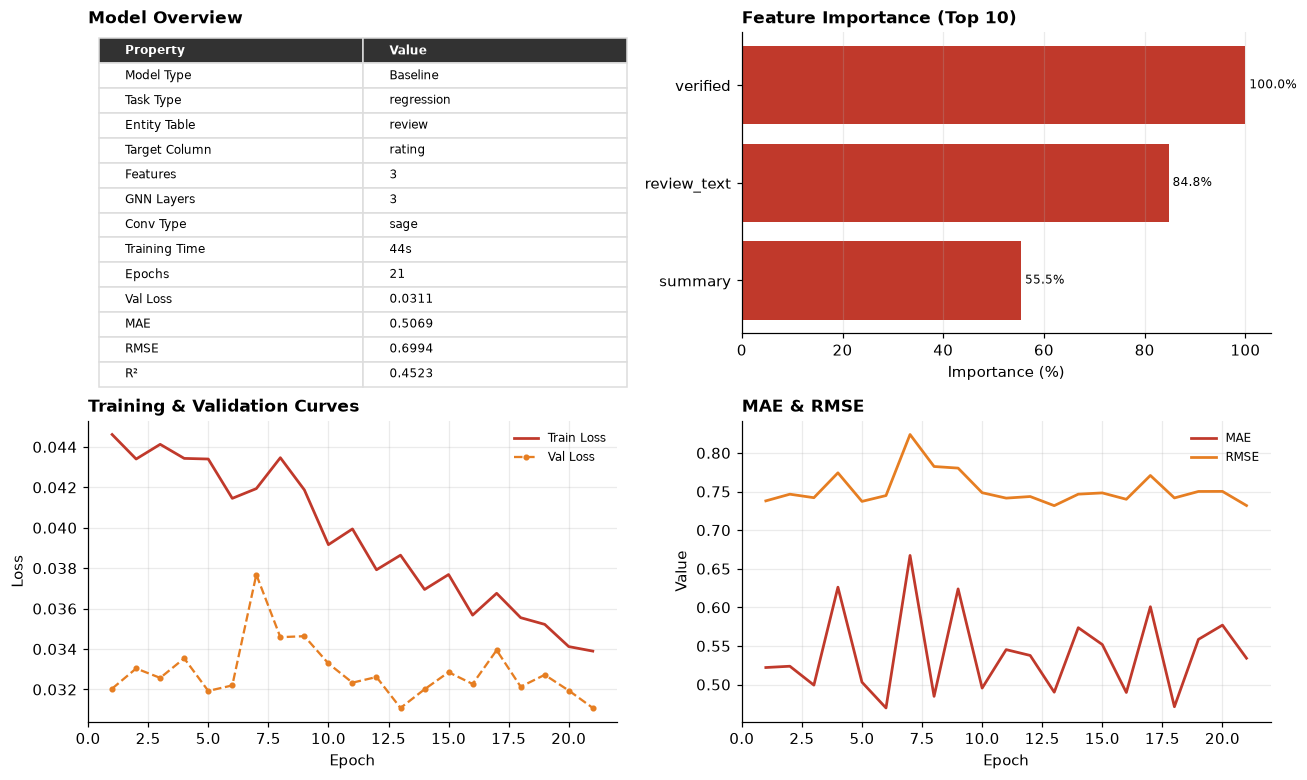

In [8]:
fig(viz.model_dashboard(p, cols=2))

In [9]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "11_finetune", "task": "fine-tune · regression on +1,000 newer reviews", "model": child.get("model_type"),
                   "project_id": p.id, "model_id": child["model_id"], "parent_model_id": parent["model_id"], "training_duration_sec": child.get("training_duration_sec"),
                   "credits_charged_this_run": charged,
                   "headline": {"parent_mae": round(parent["metrics"]["mae"], 4), "child_mae": round(child["metrics"]["mae"], 4), "child_version": child.get("version_label")},
                   "baseline": {"parent_r2": round(parent["metrics"].get("r2", 0), 4), "child_r2": round(child["metrics"].get("r2", 0), 4)}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- Cold fine-tune (`training_mode="cold"`) when the data distribution moved; `freeze_encoder=False` when you have many new rows
- [12 · Training options](../12_training_options/) — architectures and embeddings on the same task